# EFA Assumption Checks

Runs all pre- and post-EFA diagnostics. Edit the **Paths** cell before running.

**Pre-EFA:** sample size · correlation matrix · KMO & Bartlett's · normality · outliers  
**Post-EFA:** communalities · variance explained · factor loadings · cross-loadings

In [72]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

from ep_pipeline.config import MetricsConfig
from ep_pipeline.io import load_csv, write_table
from ep_pipeline.efa.efa import prepare_features, scale_metrics, parallel_analysis, plot_scree, fit_efa
from ep_pipeline.efa.metric_taxonomy import CATEGORY_OF

## Paths

In [73]:
PROJECT_ROOT = Path('/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper')
IN_FP       = PROJECT_ROOT / 'data' / 'AO3metrics_full.csv'
VIS_DIR     = PROJECT_ROOT / 'outputs' / 'visualizations'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results' / 'efa_assumptions'
VIS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cfg = MetricsConfig()

In [74]:
all_metrics = load_csv(IN_FP).drop_duplicates(subset='id').reset_index(drop=True)
feat_df, feature_cols, final_category_map, meta_df = prepare_features(
    all_metrics, CATEGORY_OF, set()
)

zero_var = [c for c in feature_cols if feat_df[c].std() == 0]
if zero_var:
    print(f"Dropping {len(zero_var)} zero-variance variable(s): {zero_var}")
    feat_df      = feat_df.drop(columns=zero_var)
    feature_cols = [c for c in feature_cols if c not in zero_var]
    final_category_map = {k: v for k, v in final_category_map.items() if k in feature_cols}

meta_full = all_metrics[[c for c in all_metrics.columns if c not in set(feature_cols) and c != 'text']]
scaled_metrics, scaler = scale_metrics(feat_df)
n_obs, n_vars = scaled_metrics.shape
corr = np.corrcoef(scaled_metrics, rowvar=False)
print(f'Loaded: {n_obs} observations x {n_vars} variables')

Dropping 2 zero-variance variable(s): ['duplicate_line_chr_fraction', 'duplicate_paragraph_chr_fraction']
Loaded: 3491 observations x 109 variables


In [75]:
dupes = all_metrics[all_metrics.duplicated(subset='id', keep=False)].sort_values('id')

exact = all_metrics.duplicated(keep=False)
print(f"Exact duplicate rows : {exact.sum()}")
print(f"Same ID, diff values : {len(dupes) - exact[dupes.index].sum()}")


Exact duplicate rows : 0
Same ID, diff values : 0


## 1. Sample size

Thresholds: N > 150 and N/variable >= 5 (ideally >= 20).

In [76]:
ratio   = n_obs / n_vars
n_pass  = 'PASS' if n_obs > 150 else 'FAIL — need >150'
r_pass  = 'PASS' if ratio >= 5  else 'FAIL — need >=5'
r2_pass = 'PASS' if ratio >= 20 else 'NOTE — ideally >=20'
print(f'N observations  : {n_obs}  ({n_pass})')
print(f'N variables     : {n_vars}')
print(f'N/variable ratio: {ratio:.1f}  ({r_pass} / {r2_pass})')

N observations  : 3491  (PASS)
N variables     : 109
N/variable ratio: 32.0  (PASS / PASS)


## 2. Correlation matrix

- Pairs with `|r| > 0.8`: multicollinearity — remove one from the pair  
- Items where max `|r| < 0.3`: too weakly correlated with everything — consider removing  
- Determinant > 1e-5: required for matrix inversion in EFA

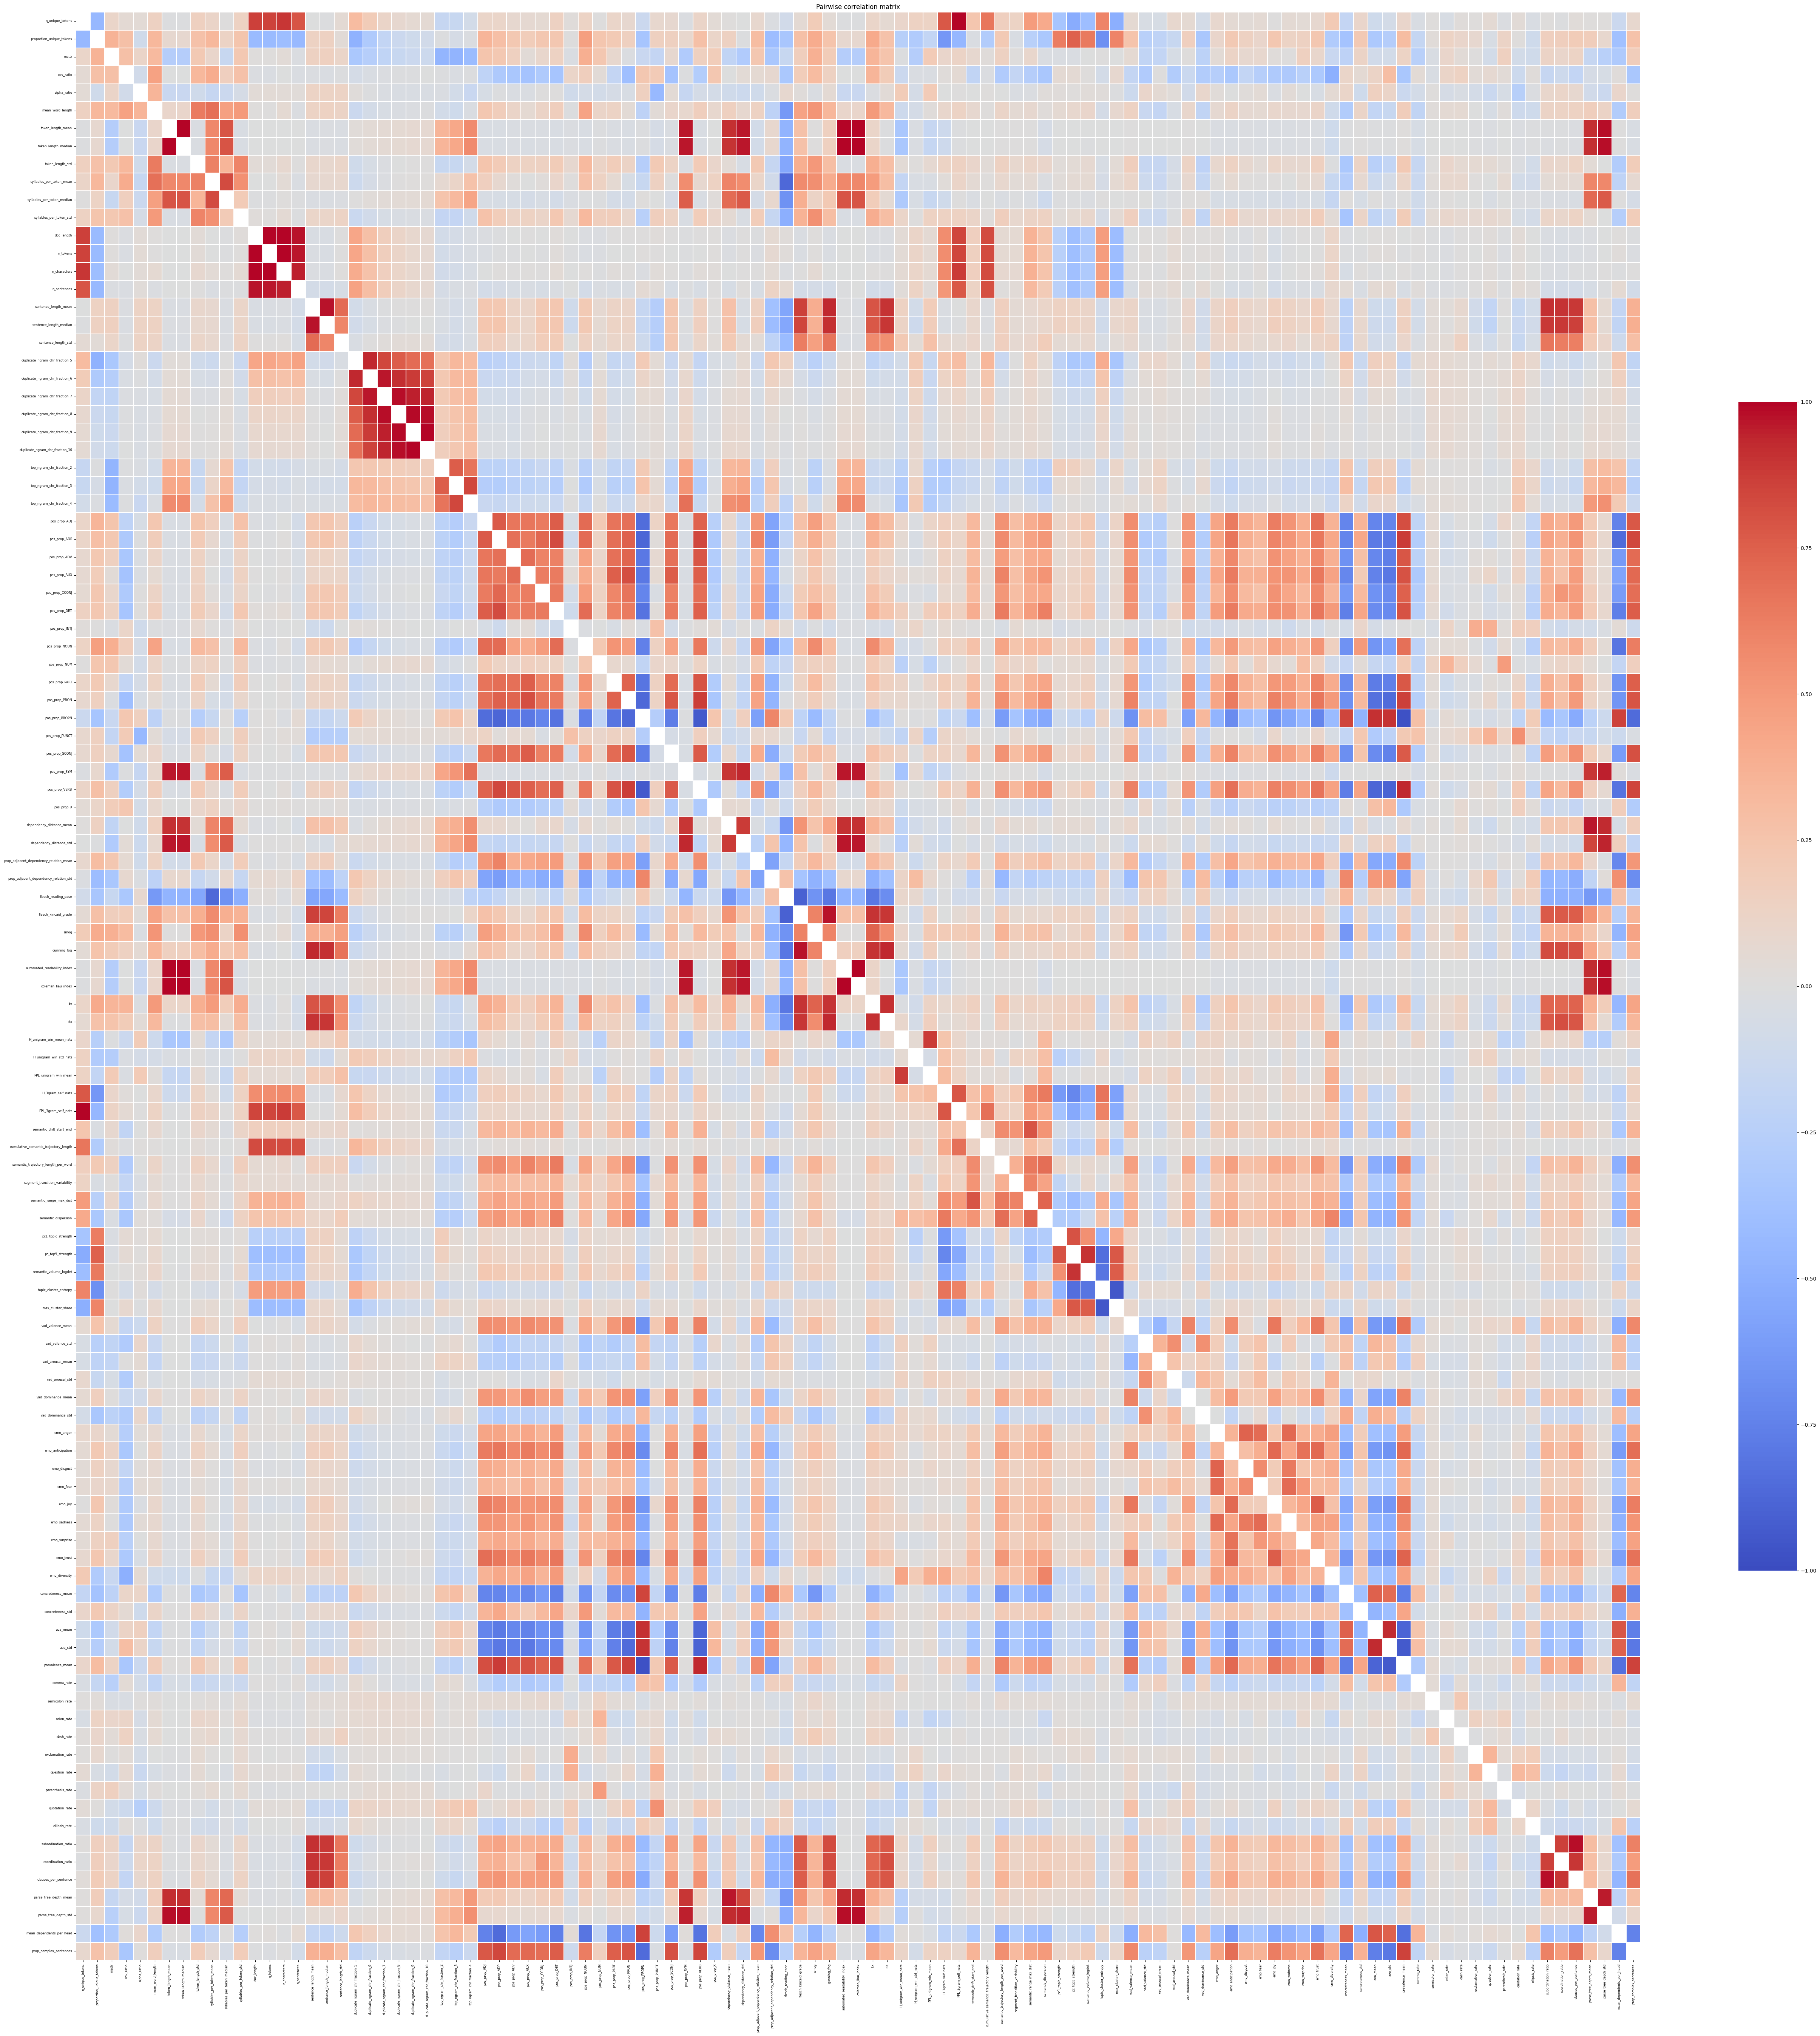

In [77]:
fig_w = max(10, n_vars // 2)
fig_h = max(8,  n_vars // 2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
mask = np.eye(n_vars, dtype=bool)
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=feature_cols, yticklabels=feature_cols,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.6}
)
ax.set_title('Pairwise correlation matrix')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
upper    = np.triu(np.abs(corr), k=1)
mc_pairs = [
    (feature_cols[i], feature_cols[j], corr[i, j])
    for i, j in zip(*np.where(upper > 0.8))
]
print(f'Multicollinearity (|r| > 0.8): {len(mc_pairs)} pair(s)')
for a, b, r in mc_pairs:
    print(f'  {a} <-> {b}:  r = {r:.3f}')

off_diag = np.abs(corr - np.eye(n_vars))
max_r    = off_diag.max(axis=1)
weak     = [(feature_cols[i], max_r[i]) for i in range(n_vars) if max_r[i] < 0.3]
print(f'\nWeak correlators (max |r| < 0.3): {len(weak)} variable(s)')
for name, r in weak:
    print(f'  {name}:  max |r| = {r:.3f}')

det      = np.linalg.det(corr)
det_pass = 'PASS' if det > 1e-5 else 'FAIL — near-singular'
print(f'\nDeterminant: {det:.2e}  ({det_pass})')

mc_df   = pd.DataFrame(mc_pairs, columns=['variable_a', 'variable_b', 'r']) if mc_pairs else pd.DataFrame(columns=['variable_a', 'variable_b', 'r'])
weak_df = pd.DataFrame(weak, columns=['variable', 'max_r']) if weak else pd.DataFrame(columns=['variable', 'max_r'])
write_table(mc_df,   RESULTS_DIR / 'corr_multicollinearity.csv')
write_table(weak_df, RESULTS_DIR / 'corr_weak_variables.csv')

Multicollinearity (|r| > 0.8): 137 pair(s)
  n_unique_tokens <-> doc_length:  r = 0.863
  n_unique_tokens <-> n_tokens:  r = 0.859
  n_unique_tokens <-> n_characters:  r = 0.891
  n_unique_tokens <-> PPL_3gram_self_nats:  r = 0.994
  token_length_mean <-> token_length_median:  r = 1.000
  token_length_mean <-> pos_prop_SYM:  r = 0.963
  token_length_mean <-> dependency_distance_mean:  r = 0.906
  token_length_mean <-> dependency_distance_std:  r = 0.962
  token_length_mean <-> automated_readability_index:  r = 1.000
  token_length_mean <-> coleman_liau_index:  r = 1.000
  token_length_mean <-> parse_tree_depth_mean:  r = 0.920
  token_length_mean <-> parse_tree_depth_std:  r = 0.981
  token_length_median <-> pos_prop_SYM:  r = 0.963
  token_length_median <-> dependency_distance_mean:  r = 0.906
  token_length_median <-> dependency_distance_std:  r = 0.962
  token_length_median <-> automated_readability_index:  r = 1.000
  token_length_median <-> coleman_liau_index:  r = 1.000
  token_l

In [79]:
rows = []
for i, (a, b, r_ab) in enumerate(mc_pairs, 1):
    others  = [c for c in feature_cols if c not in (a, b)]
    idx_a   = feature_cols.index(a)
    idx_b   = feature_cols.index(b)
    idx_o   = [feature_cols.index(c) for c in others]
    reach_a = np.nanmean(np.abs(corr[idx_a][idx_o]))
    reach_b = np.nanmean(np.abs(corr[idx_b][idx_o]))
    keep    = a if reach_a >= reach_b else b
    drop    = b if keep == a else a

    print(f"Pair {i}/{len(mc_pairs)}:  {a}  <->  {b}  (r = {r_ab:.3f})")
    print(f"  {a:<50}  reach = {reach_a:.3f}")
    print(f"  {b:<50}  reach = {reach_b:.3f}")
    print(f"  --> KEEP: {keep}")
    print(f"      DROP: {drop}")
    print()

    rows.append({
        'variable_a': a, 'variable_b': b, 'r': round(r_ab, 3),
        'reach_a': round(reach_a, 3), 'reach_b': round(reach_b, 3),
        'recommended_keep': keep, 'recommended_drop': drop,
    })

mc_recommendation_df = pd.DataFrame(rows)
write_table(mc_recommendation_df, RESULTS_DIR / 'corr_multicollinearity_recommendations.csv')
print(f"Saved recommendations for {len(rows)} pair(s).")

Pair 1/137:  n_unique_tokens  <->  doc_length  (r = 0.863)
  n_unique_tokens                                     reach = 0.146
  doc_length                                          reach = 0.104
  --> KEEP: n_unique_tokens
      DROP: doc_length

Pair 2/137:  n_unique_tokens  <->  n_tokens  (r = 0.859)
  n_unique_tokens                                     reach = 0.146
  n_tokens                                            reach = 0.105
  --> KEEP: n_unique_tokens
      DROP: n_tokens

Pair 3/137:  n_unique_tokens  <->  n_characters  (r = 0.891)
  n_unique_tokens                                     reach = 0.146
  n_characters                                        reach = 0.105
  --> KEEP: n_unique_tokens
      DROP: n_characters

Pair 4/137:  n_unique_tokens  <->  PPL_3gram_self_nats  (r = 0.994)
  n_unique_tokens                                     reach = 0.145
  PPL_3gram_self_nats                                 reach = 0.145
  --> KEEP: PPL_3gram_self_nats
      DROP: n_unique_to

In [80]:
# Build adjacency list from collinear pairs
neighbours = defaultdict(set)
for a, b, _ in mc_pairs:
    neighbours[a].add(b)
    neighbours[b].add(a)

remaining = set(feature_cols)
to_drop   = set()

while True:
    # Find all edges that still exist among remaining variables
    active_edges = [
        (a, b) for a, b, _ in mc_pairs
        if a in remaining and b in remaining
    ]
    if not active_edges:
        break

    # Count collinear neighbours still in play for each variable
    degree = defaultdict(int)
    for a, b in active_edges:
        degree[a] += 1
        degree[b] += 1

    # Drop the variable with the most collinear neighbours;
    # break ties by choosing the one with the lower reach
    max_deg  = max(degree.values())
    tied     = [v for v, d in degree.items() if d == max_deg]
    idx_map  = {c: i for i, c in enumerate(feature_cols)}
    drop_var = min(tied, key=lambda v: np.nanmean(np.abs(corr[idx_map[v]][[idx_map[c] for c in feature_cols if c != v]])))

    to_drop.add(drop_var)
    remaining.discard(drop_var)

print(f"Variables to drop  : {len(to_drop)}")
print(f"Variables to keep  : {len(remaining)}")
print(f"\nDROP ({len(to_drop)}):")
for v in sorted(to_drop):
    print(f"  {v}")

drop_df = pd.DataFrame(sorted(to_drop), columns=['variable'])
write_table(drop_df, RESULTS_DIR / 'collinearity_drop_list.csv')

Variables to drop  : 37
Variables to keep  : 72

DROP (37):
  PPL_unigram_win_mean
  aoa_std
  automated_readability_index
  coleman_liau_index
  coordination_ratio
  cumulative_semantic_trajectory_length
  dependency_distance_mean
  dependency_distance_std
  doc_length
  duplicate_ngram_chr_fraction_10
  duplicate_ngram_chr_fraction_6
  duplicate_ngram_chr_fraction_7
  duplicate_ngram_chr_fraction_9
  flesch_kincaid_grade
  gunning_fog
  n_characters
  n_tokens
  n_unique_tokens
  parse_tree_depth_std
  pc_top5_strength
  pos_prop_ADP
  pos_prop_NOUN
  pos_prop_PRON
  pos_prop_PROPN
  pos_prop_SCONJ
  pos_prop_SYM
  pos_prop_VERB
  prevalence_mean
  rix
  sentence_length_mean
  sentence_length_median
  subordination_ratio
  syllables_per_token_mean
  token_length_mean
  token_length_median
  top_ngram_chr_fraction_4
  topic_cluster_entropy


In [81]:
idx_map_all  = {c: i for i, c in enumerate(feature_cols)}
reach_all    = {
    v: np.nanmean(np.abs(corr[idx_map_all[v]][[idx_map_all[c] for c in feature_cols if c != v]]))
    for v in feature_cols
}
orig_degree = defaultdict(int)
for a, b, _ in mc_pairs:
    orig_degree[a] += 1
    orig_degree[b] += 1

summary_df = pd.DataFrame([{
    'variable':        v,
    'category':        CATEGORY_OF.get(v, 'unknown'),
    'status':          'DROP' if v in to_drop else 'KEEP',
    'reach':           round(reach_all[v], 3),
    'collinear_pairs': orig_degree.get(v, 0),
} for v in feature_cols]).sort_values(
    ['category', 'status', 'reach'], ascending=[True, True, False]
)

for cat, grp in summary_df.groupby('category'):
    n_keep = (grp['status'] == 'KEEP').sum()
    n_drop = (grp['status'] == 'DROP').sum()
    print(f"\n{'='*65}")
    print(f"  {cat}  —  keep {n_keep}  /  drop {n_drop}")
    print(f"{'='*65}")
    print(grp[['status', 'variable', 'reach', 'collinear_pairs']].to_string(index=False))

write_table(summary_df, RESULTS_DIR / 'collinearity_summary_by_category.csv')


  Affect Dimensions  —  keep 6  /  drop 0
status           variable  reach  collinear_pairs
  KEEP   vad_valence_mean  0.226                0
  KEEP vad_dominance_mean  0.195                0
  KEEP  vad_dominance_std  0.139                0
  KEEP    vad_valence_std  0.123                0
  KEEP   vad_arousal_mean  0.115                0
  KEEP    vad_arousal_std  0.065                0

  Clustering & Diversity  —  keep 1  /  drop 1
status              variable  reach  collinear_pairs
  DROP topic_cluster_entropy  0.144                3
  KEEP     max_cluster_share  0.129                1

  Coherence & Trajectory  —  keep 4  /  drop 1
status                              variable  reach  collinear_pairs
  DROP cumulative_semantic_trajectory_length  0.093                4
  KEEP   semantic_trajectory_length_per_word  0.230                0
  KEEP               semantic_range_max_dist  0.229                0
  KEEP              semantic_drift_start_end  0.165                0
  KEEP 

In [82]:
n_tokens_vals = all_metrics['n_tokens'].values
length_corr = pd.Series(
    {col: np.corrcoef(feat_df[col].values, n_tokens_vals)[0, 1] for col in feature_cols},
    name='r_with_n_tokens'
).sort_values(key=abs, ascending=False)

print(length_corr.head(10).to_string())

n_tokens                                 1.000000
doc_length                               0.999172
n_characters                             0.993418
n_sentences                              0.967777
n_unique_tokens                          0.859226
PPL_3gram_self_nats                      0.847746
cumulative_semantic_trajectory_length    0.826241
H_3gram_self_nats                        0.555361
topic_cluster_entropy                    0.484168
duplicate_ngram_chr_fraction_5           0.431905


In [91]:
# --- Manual overrides to greedy drop list ---
#
# 1. PPL_3gram_self_nats: algorithm kept it (n_unique_tokens was dropped instead),
# but it's a self-referential length artifact (r=0.848 with n_tokens)
#
# 2. POS proportions sum to ~1 (structural collinearity), so the greedy algorithm
# dropped the four most important narrative POS tags. Override: rescue NOUN, VERB,
# PRON (core style signals — content vs. function words, person/voice), and keep
# PROPN dropped as the cross-category hub driving most of the collinearity.
#
# 3. H_unigram_win_std_nats: weak correlator (max |r| = 0.298) flagged above.
# A std-only metric that barely relates to anything else is likely noise. Drop it.

force_drop   = {'PPL_3gram_self_nats', 'H_unigram_win_std_nats', 'alpha_ratio', 'parenthesis_rate', 'duplicate_ngram_chr_fraction_8'} # removed parenthesis rate, duplicate ngram 8, and alpha_ratio because of tests below
force_rescue = {'pos_prop_NOUN', 'pos_prop_VERB', 'pos_prop_PRON'}

to_drop = (to_drop | force_drop) - force_rescue

print("Manual overrides applied:")
print(f"  Added to drop    : {sorted(force_drop)}")
print(f"  Rescued from drop: {sorted(force_rescue)}")
print(f"\nFinal drop count : {len(to_drop)}")
print(f"Final keep count : {len(feature_cols) - len(to_drop)}")

Manual overrides applied:
  Added to drop    : ['H_unigram_win_std_nats', 'PPL_3gram_self_nats', 'alpha_ratio', 'duplicate_ngram_chr_fraction_8', 'parenthesis_rate']
  Rescued from drop: ['pos_prop_NOUN', 'pos_prop_PRON', 'pos_prop_VERB']

Final drop count : 39
Final keep count : 70


In [92]:
# Apply collinearity drop list — create cleaned variable set for KMO and beyond
keep_cols      = [c for c in feature_cols if c not in to_drop]
keep_idx       = [feature_cols.index(c) for c in keep_cols]
scaled_clean   = scaled_metrics[:, keep_idx]
category_clean = {c: final_category_map[c] for c in keep_cols}
corr_clean     = np.corrcoef(scaled_clean, rowvar=False)

det_clean = np.linalg.det(corr_clean)
print(f"Variables after collinearity resolution : {len(keep_cols)}")
print(f"Determinant (cleaned matrix)            : {det_clean:.2e}")

Variables after collinearity resolution : 70
Determinant (cleaned matrix)            : 5.01e-30


## 3. KMO & Bartlett's test

- Overall KMO >= 0.60 (adequate) / >= 0.80 (good)  
- Bartlett p < 0.05: correlation matrix is not an identity matrix  
- Per-variable MSA >= 0.50: items below this are candidates for removal

### With parenthesis rate, duplicate ngram 8, and alpha_ratio

In [93]:
kmo_all, kmo_model = calculate_kmo(scaled_clean)
chi2, p_val        = calculate_bartlett_sphericity(scaled_clean)

kmo_pass  = 'PASS' if kmo_model >= 0.6 else 'FAIL — need >=0.60'
bart_pass = 'PASS' if p_val < 0.05     else 'FAIL — need p<0.05'
print(f'Overall KMO     : {kmo_model:.3f}  ({kmo_pass})')
print(f'Bartlett p-value: {p_val:.2e}  ({bart_pass})')

msa_series = pd.Series(kmo_all, index=keep_cols).sort_values()
low_msa    = msa_series[msa_series < 0.5]
print(f'\nPer-variable MSA < 0.50: {len(low_msa)} variable(s)')
if not low_msa.empty:
    print(low_msa.to_string())

Overall KMO     : 0.890  (PASS)
Bartlett p-value: 0.00e+00  (PASS)

Per-variable MSA < 0.50: 0 variable(s)


/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


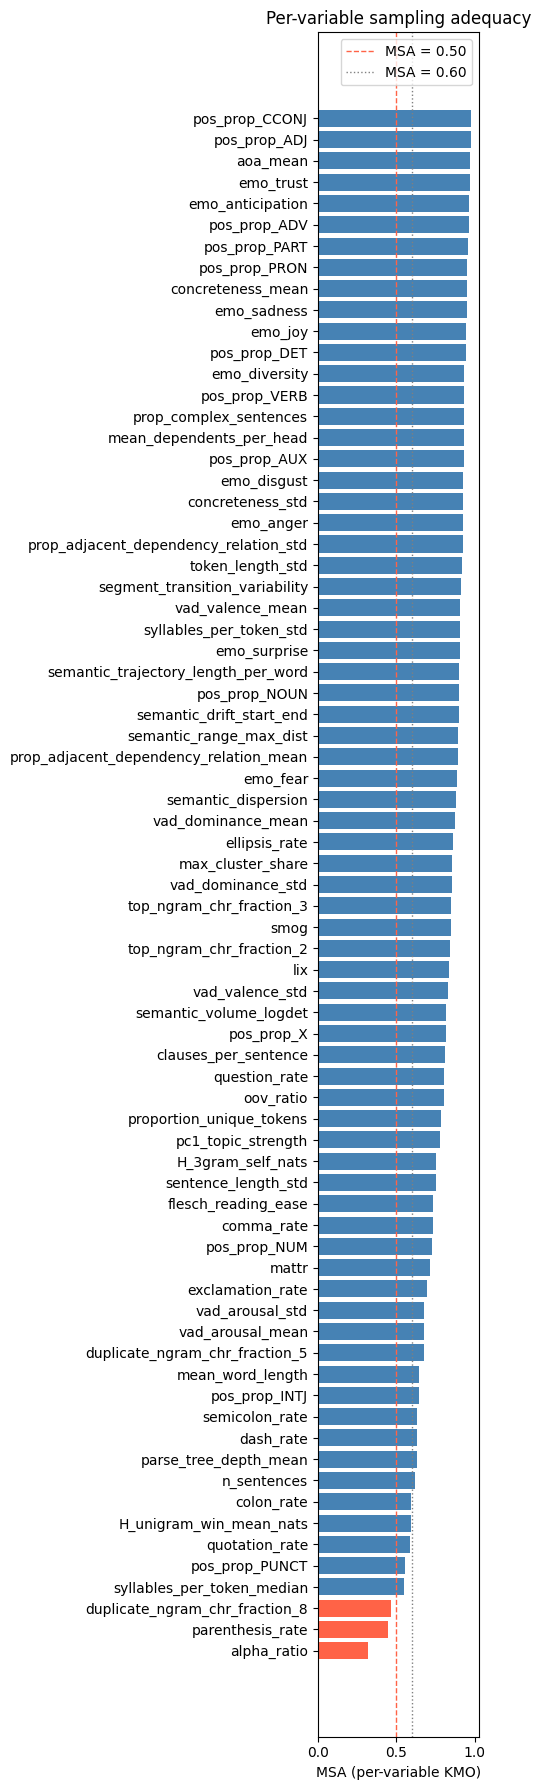

In [86]:
fig, ax = plt.subplots(figsize=(5, max(6, len(keep_cols) // 4)))
colors  = ['tomato' if v < 0.5 else 'steelblue' for v in msa_series.values]
ax.barh(msa_series.index, msa_series.values, color=colors)
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1, label='MSA = 0.50')
ax.axvline(0.6, color='gray',   linestyle=':',  linewidth=1, label='MSA = 0.60')
ax.set_xlabel('MSA (per-variable KMO)')
ax.set_title('Per-variable sampling adequacy')
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_msa.png', dpi=150, bbox_inches='tight')
plt.show()

### Without parenthesis rate, duplicate ngram 8, and alpha_ratio

In [94]:
kmo_all, kmo_model = calculate_kmo(scaled_clean)
chi2, p_val        = calculate_bartlett_sphericity(scaled_clean)

kmo_pass  = 'PASS' if kmo_model >= 0.6 else 'FAIL — need >=0.60'
bart_pass = 'PASS' if p_val < 0.05     else 'FAIL — need p<0.05'
print(f'Overall KMO     : {kmo_model:.3f}  ({kmo_pass})')
print(f'Bartlett p-value: {p_val:.2e}  ({bart_pass})')

msa_series = pd.Series(kmo_all, index=keep_cols).sort_values()
low_msa    = msa_series[msa_series < 0.5]
print(f'\nPer-variable MSA < 0.50: {len(low_msa)} variable(s)')
if not low_msa.empty:
    print(low_msa.to_string())

Overall KMO     : 0.890  (PASS)
Bartlett p-value: 0.00e+00  (PASS)

Per-variable MSA < 0.50: 0 variable(s)


/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


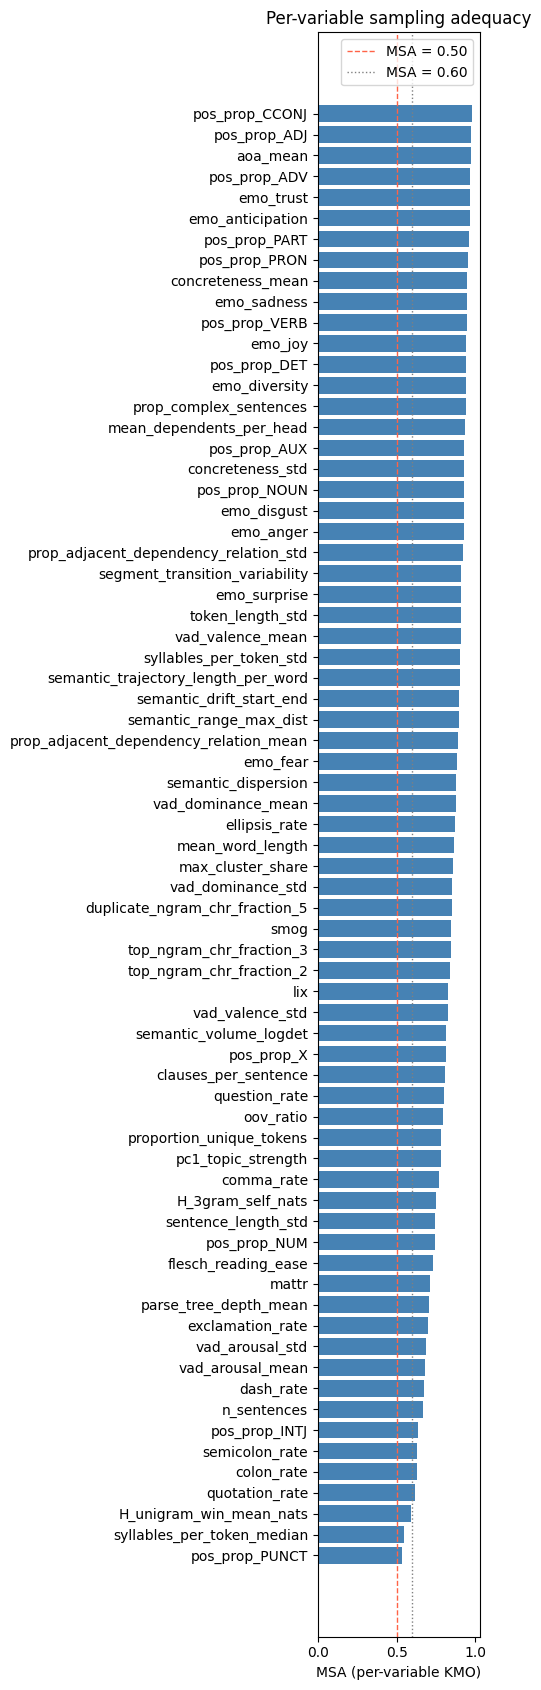

In [95]:
fig, ax = plt.subplots(figsize=(5, max(6, len(keep_cols) // 4)))
colors  = ['tomato' if v < 0.5 else 'steelblue' for v in msa_series.values]
ax.barh(msa_series.index, msa_series.values, color=colors)
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1, label='MSA = 0.50')
ax.axvline(0.6, color='gray',   linestyle=':',  linewidth=1, label='MSA = 0.60')
ax.set_xlabel('MSA (per-variable KMO)')
ax.set_title('Per-variable sampling adequacy')
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / 'noalpharatio_efa_msa.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Normality

EFA is robust to mild non-normality. Flag variables with `|skew| > 2` or `|kurt| > 7`; consider log or sqrt transformation if needed.

In [97]:
norm_df = pd.DataFrame({
    'skewness': stats.skew(scaled_clean),
    'kurtosis': stats.kurtosis(scaled_clean),
}, index=keep_cols).sort_values('skewness', key=abs, ascending=False)

flagged = norm_df[(norm_df['skewness'].abs() > 2) | (norm_df['kurtosis'].abs() > 7)]
print(f'Variables flagged (|skew|>2 or |kurt|>7): {len(flagged)}')
print(norm_df.to_string())

Variables flagged (|skew|>2 or |kurt|>7): 43
                                         skewness     kurtosis
parse_tree_depth_mean                   46.081425  2494.639861
syllables_per_token_median              36.613637  1512.819735
token_length_std                        20.447571   592.113144
semicolon_rate                          16.067114   507.137171
pos_prop_NUM                            15.678432   382.742066
top_ngram_chr_fraction_3                15.010104   401.585220
pos_prop_X                              14.959274   384.374812
flesch_reading_ease                    -13.664664   307.751574
emo_surprise                            13.552032   457.466776
colon_rate                              13.451041   258.280220
mean_word_length                        13.370912   389.863765
clauses_per_sentence                    12.183835   311.766759
H_unigram_win_mean_nats                -12.175377   188.943207
quotation_rate                          11.114438   289.683500
top_ngram_

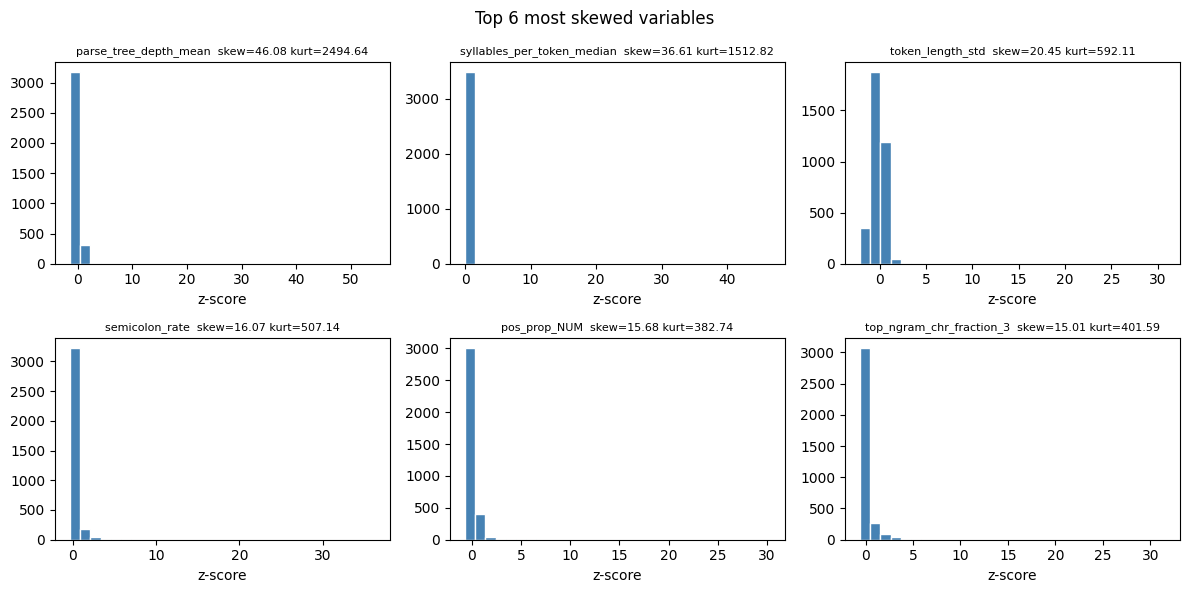

In [98]:
top_vars = norm_df.head(min(6, len(norm_df))).index.tolist()
idx_map  = {c: i for i, c in enumerate(feature_cols)}
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for ax, col in zip(axes, top_vars):
    ax.hist(scaled_metrics[:, idx_map[col]], bins=30, color='steelblue', edgecolor='white')
    skew_val = norm_df.loc[col, 'skewness']
    kurt_val = norm_df.loc[col, 'kurtosis']
    ax.set_title(f'{col}  skew={skew_val:.2f} kurt={kurt_val:.2f}', fontsize=8)
    ax.set_xlabel('z-score')
for ax in axes[len(top_vars):]:
    ax.set_visible(False)
plt.suptitle('Top 6 most skewed variables')
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_norm_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Outliers

Per-variable z-scores: flag observations where any variable has `|z| > 3.5`.  
Since `scaled_metrics` is already standardised, each column is directly on the z-score scale.

In [ ]:
z_max        = np.abs(scaled_clean).max(axis=1)
outlier_mask = z_max > 3.5
n_out        = int(outlier_mask.sum())
print(f'Observations with any |z| > 3.5: {n_out} ({100 * n_out / n_obs:.1f}%)')

if n_out > 0:
    out_idx   = np.where(outlier_mask)[0]
    worst_var = [keep_cols[np.abs(scaled_clean[i]).argmax()] for i in out_idx]
    out_df    = meta_full.iloc[out_idx].copy().reset_index(drop=True)
    out_df['max_z']          = z_max[outlier_mask]
    out_df['worst_variable'] = worst_var
    print(out_df.sort_values('max_z', ascending=False).head(20).to_string())

## 6. Factor number — parallel analysis & scree

Retains factors whose eigenvalues exceed the 95th percentile from random data of the same shape.  
The Kaiser criterion (eigenvalue > 1) is shown for reference.

In [ ]:
eigenvalues, pa_95th, n_factors = parallel_analysis(
    scaled_metrics, seed=cfg.seed, n_perm=cfg.n_permutations
)
n_kaiser = int((eigenvalues > 1).sum())
print(f'Parallel analysis suggests : {n_factors} factor(s)')
print(f'Kaiser criterion (eig > 1) : {n_kaiser} factor(s)')
plot_scree(eigenvalues, pa_95th, n_factors, viz_path=VIS_DIR / 'efa_scree.png')
plt.show()

## 7. Fit EFA

Uses `n_factors` from parallel analysis above. Uncomment the override line if the scree plot or theory suggests a different number.

In [ ]:
# n_factors = 5  # uncomment to override

fa, loadings_df, var_df = fit_efa(
    scaled_metrics, feature_cols, final_category_map, n_factors
)
print(var_df.to_string(index=False))
total_var = var_df['cumulative_pct'].iloc[-1]
var_pass  = 'PASS' if total_var >= 50 else 'NOTE — below 50%'
print(f'\nTotal variance explained: {total_var:.1f}%  ({var_pass})')

## 8. Communalities

Variables with h2 < 0.30 are poorly explained by the retained factors — consider removing and refitting.

In [ ]:
communalities = fa.get_communalities()
comm_series   = pd.Series(communalities, index=feature_cols).sort_values()
low_comm      = comm_series[comm_series < 0.3]
print(f'Low communalities (h2 < 0.30): {len(low_comm)} variable(s)')
if not low_comm.empty:
    print(low_comm.to_string())

fig, ax = plt.subplots(figsize=(5, max(6, n_vars // 4)))
colors  = ['tomato' if v < 0.3 else 'steelblue' for v in comm_series.values]
ax.barh(comm_series.index, comm_series.values, color=colors)
ax.axvline(0.3, color='tomato', linestyle='--', linewidth=1, label='h2 = 0.30')
ax.set_xlabel('Communality (h2)')
ax.set_title('Communalities — post-EFA')
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_communalities.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Factor loadings & cross-loadings

- **Weak loaders** (`max |loading| < 0.30`): item does not load sufficiently on any factor — consider dropping  
- **Cross-loaders** (2nd highest loading > 75% of highest): item is ambiguous across factors — consider dropping

In [ ]:
factor_col_names = [f'F{i+1}' for i in range(n_factors)]
loadings_vals    = loadings_df[factor_col_names]

annot = n_vars <= 40
fig, ax = plt.subplots(figsize=(max(6, n_factors + 2), max(8, n_vars // 3)))
sns.heatmap(
    loadings_vals, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=annot, fmt='.2f', linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Factor loadings (pattern matrix)')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
abs_loadings = loadings_vals.abs()
max_loading  = abs_loadings.max(axis=1)

weak_loaders = max_loading[max_loading < 0.3]
print(f'Weak loaders (max |loading| < 0.30): {len(weak_loaders)} variable(s)')
if not weak_loaders.empty:
    print(weak_loaders.to_string())

cross_loaders = []
for var in abs_loadings.index:
    row = abs_loadings.loc[var].sort_values(ascending=False)
    if n_factors >= 2 and row.iloc[1] > 0.75 * row.iloc[0]:
        cross_loaders.append({
            'variable':          var,
            'primary_factor':    row.index[0],
            'primary_loading':   row.iloc[0],
            'secondary_factor':  row.index[1],
            'secondary_loading': row.iloc[1],
        })

print(f'\nCross-loaders (2nd loading > 75% of 1st): {len(cross_loaders)} variable(s)')
if cross_loaders:
    print(pd.DataFrame(cross_loaders).to_string(index=False))